In [23]:
import pandas as pd
import yfinance as yf
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import scipy.optimize as sop

In [24]:
lista_nombres = ["COPEC.SN", "FALABELLA.SN", "CMPC.SN"]
brutos = yf.download(tickers = lista_nombres, period= "2y")
valores_cierre = brutos["Close"]

[*********************100%***********************]  3 of 3 completed


In [25]:
retornos_diarios = valores_cierre.pct_change()
vector_pesos = np.array([0.1, 0.1, 0.8])

In [26]:
retornos_medios = retornos_diarios.mean()
retorno_portafolio = np.dot(retornos_medios, vector_pesos)
print(retorno_portafolio)

0.0012323055307597486


In [27]:
covarianza_portafolio = retornos_diarios.cov()
covarianza_portafolio


Ticker,CMPC.SN,COPEC.SN,FALABELLA.SN
Ticker,,,
CMPC.SN,0.000294,0.000143,0.000111
COPEC.SN,0.000143,0.000225,0.000087
FALABELLA.SN,0.000111,0.000087,0.000284


In [28]:
varianza = np.dot(vector_pesos, np.dot(covarianza_portafolio, vector_pesos))
dst = np.sqrt(varianza)
print(dst)
sharpe = retorno_portafolio/dst
print(sharpe)

0.014880258426799872
0.08281479362887427


In [29]:
pesosgrandes = np.random.random(3)
pesos = pesosgrandes/pesosgrandes.sum()

In [30]:
def funcion_definicon(pesos):
    vector_pesos = np.array([pesos[0], pesos[1], pesos[2]])
    retorno_portafolio = np.dot(retornos_medios, vector_pesos)
    varianza = np.dot(vector_pesos, np.dot(covarianza_portafolio, vector_pesos))
    dst = np.sqrt(varianza)
    sharpe = retorno_portafolio/dst
    return [sharpe, retorno_portafolio, dst, pesos]

In [31]:
resultadosfinales = []
for i in range(10000):
    pesosgrandes = np.random.random(3)
    pesos = pesosgrandes/pesosgrandes.sum()
    resultadocadapeso = funcion_definicon(pesos)
    resultadosfinales.append(resultadocadapeso)
resultadosfinales.sort()
print(resultadosfinales)

[[np.float64(-0.051173938480543586), np.float64(-0.0008409247377226874), np.float64(0.01643267574651125), array([0.91523668, 0.08330639, 0.00145693])], [np.float64(-0.05091873059862996), np.float64(-0.000833138954894753), np.float64(0.016362131284497688), array([0.9066384 , 0.09107443, 0.00228718])], [np.float64(-0.05060954829679642), np.float64(-0.0008474630931110553), np.float64(0.016745122642493525), array([0.95643511, 0.02949703, 0.01406787])], [np.float64(-0.05021932533883566), np.float64(-0.0008208456593680248), np.float64(0.016345214791908952), array([0.90655812, 0.08455782, 0.00888406])], [np.float64(-0.04961009586158826), np.float64(-0.0008156584229312742), np.float64(0.016441379698337092), array([0.92081513, 0.06191985, 0.01726501])], [np.float64(-0.04904179915665809), np.float64(-0.0008166802525639654), np.float64(0.01665273841106806), array([0.94847273, 0.02398048, 0.02754678])], [np.float64(-0.048837522566293486), np.float64(-0.0007817650822623085), np.float64(0.0160074680

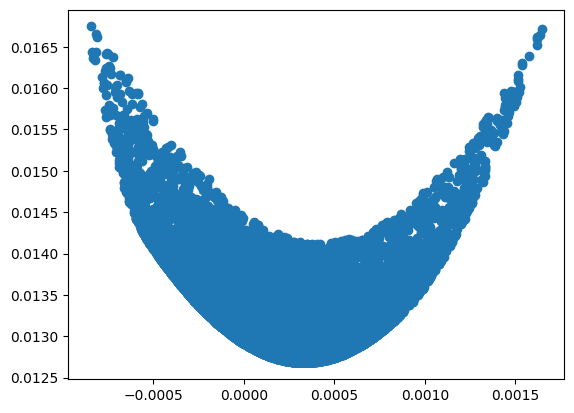

In [32]:
retornos = [r[1] for r in resultadosfinales]
volatilidades = [r[2] for r in resultadosfinales]
plt.scatter(retornos, volatilidades)

In [33]:
mejor = resultadosfinales[-1]
print("Sharpe:", mejor[0])
print("Retorno:", mejor[1])
print("Volatilidad:", mejor[2])
print("Pesos:", mejor[3])


Sharpe: 0.09840294131235829
Retorno: 0.0016453499408480904
Volatilidad: 0.016720536184231447
Pesos: [0.01040352 0.00198275 0.98761373]


In [34]:
def sharpe_negativo(pesos):
    return -(funcion_definicon(pesos)[0])

In [43]:
sop.minimize(sharpe_negativo,
            x0 = [1/3, 1/3, 1/3],
            constraints={'type': 'eq', 'fun': lambda w: w.sum() - 1},
            bounds=[(0, 1), (0, 1), (0, 1)]
        )

     message: Optimization terminated successfully
     success: True
      status: 0
         fun: -0.09946038883856989
           x: [ 0.000e+00  5.551e-17  1.000e+00]
         nit: 5
         jac: [ 9.246e-02  4.120e-02 -0.000e+00]
        nfev: 20
        njev: 5
 multipliers: [ 4.120e-02]

In [44]:
def funcion_dst(pesos):
    vector_pesos = np.array([pesos[0], pesos[1], pesos[2]])
    return np.sqrt(np.dot(vector_pesos, np.dot(covarianza_portafolio, vector_pesos)))

In [54]:
posibles_retornos = np.linspace(np.dot(retornos_medios, [1, 0, 0]), np.dot(retornos_medios, [0, 0, 1]), 50)
lista_mejores_pesos_por_cada_retorno = []
for i in posibles_retornos:
    resultado = sop.minimize(funcion_dst,
             x0 = [1,0,0],
             constraints=[{'type':'eq', 'fun':lambda w: w.sum() - 1},
                           {'type':'eq', 'fun': lambda w: np.dot(retornos_medios, w) - i}],
             bounds = [(0, 1), (0, 1), (0, 1)])
    lista_mejores_pesos_por_cada_retorno.append([i, resultado.fun, resultado.x])

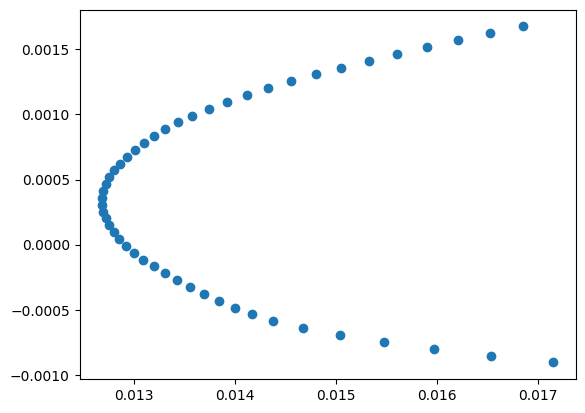

In [57]:
volatilidad = [r[1] for r in lista_mejores_pesos_por_cada_retorno]
retorno = [r[0] for r in lista_mejores_pesos_por_cada_retorno]
plt.scatter(volatilidad, retorno)